#**💻Weekly Extreme Analysis: Frequency, Mean, and Max Intensity**

> **Updated** 03-Dec-2025 <br/>
> **Team** ART(AI-based prediction Research and Technology)/APCC(APEC Climate Center)<br/>
> **Contact** Miae Kim (miaekim@apcc21.org)
<br/>

In this notebook, you will analyze weekly averaged or accumulated climate extremes from ERA5 over East Asia. You will calculate climatological weekly extreme statistics (frequency, mean intensity, max intensity) and visualize them spatially.

NOTE: The codes for calculating extreme statistics were written to handle the limited RAM constraints of Google Colab through use of Dask chunking.

## ⚙️**Requirements**

***"You can mount /content/drive/ to your Google Drive, where you will download data from the GitHub page(https://github.com/yyalexlee/EastAsiaClimateExtremes/tree/main)."***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Set paths**

CHANGE the following paths if needed!

In [ ]:
PATH_data = "/content/drive/MyDrive/APCC/Data/weekly/"
PATH_clim = "/content/drive/MyDrive/APCC/Data/climatology/"
PATH_save = "/content/drive/MyDrive/APCC/Results/"

## **Import libraries**

In [ ]:
!pip install cartopy

In [ ]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cartopy.crs as ccrs
import dask
from dask.diagnostics import ProgressBar

This is to define the min and max values of colorbar automatically.

In [ ]:
def get_vmin_vmax(data, percentile_min=2, percentile_max=98):
    valid_data = data.values[~np.isnan(data.values)].flatten()
    if len(valid_data) == 0:
        print(f"Warning: No valid data found. Using data min/max instead.")
        vmin = float(np.nanmin(data.values))
        vmax = float(np.nanmax(data.values))
    else:
        vmin = float(np.percentile(valid_data, percentile_min))
        vmax = float(np.percentile(valid_data, percentile_max))
    return vmin, vmax

## **Set options**

Percentile threshold for extremes, Climatology reference period, Domain of interest


In [ ]:
boundary = 0.90
ref_syear, ref_eyear = 1991, 2020

lon_min, lon_max = 114, 141
lat_min, lat_max = 21, 48

## **Load pre-computed 7-Day Rolling Averages / Sums and 90th percentile threshold**

***"You CAN change the target variable BELOW."***

In [ ]:
varname = 'AHT' # AHT, HR, MHW

In [ ]:
if varname == 'AHT':
    ds = xr.open_dataset(
        os.path.join(PATH_data, "ERA5_7day_rolling_T2m_1940_2024.nc"),
        chunks={'time': 180, 'latitude': 30, 'longitude': 30} # Chunks!
    )
    data = ds.t2m_7day
    data = data.sel(time=data.time.dt.dayofweek == 0)
    threshold_file = os.path.join(PATH_clim, "T2m_climatology_dataset.nc")
    thresholds = xr.open_dataset(threshold_file)
    threshold = thresholds[f"clim_{int(boundary*100)}th"]
    threshold -= 273.15
    unit = 'degC'

elif varname == 'HR':
    ds = xr.open_dataset(
        os.path.join(PATH_data, "ERA5_7day_rolling_TP_1940_2024.nc"),
        chunks={'time': 180, 'latitude': 30, 'longitude': 30}
    )
    data = ds.tp_7day
    data = data.sel(time=data.time.dt.dayofweek == 0)
    threshold_file = os.path.join(PATH_clim, "TP_climatology_dataset.nc")
    thresholds = xr.open_dataset(threshold_file)
    threshold = thresholds[f"clim_{int(boundary*100)}th"]
    unit = 'mm'

elif varname == 'MHW':
    ds = xr.open_dataset(
        os.path.join(PATH_data, "ERA5_7day_rolling_SST_1940_2024.nc"),
        chunks={'time': 180, 'latitude': 30, 'longitude': 30}
    )
    data = ds.sst_7day
    data = data.sel(time=data.time.dt.dayofweek == 0)
    threshold_file = os.path.join(PATH_clim, "SST_climatology_dataset.nc")
    thresholds = xr.open_dataset(threshold_file)
    threshold = thresholds[f"clim_{int(boundary*100)}th"]
    unit = 'degC'

/tmp/ipython-input-1166455897.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(


Selecting region of interest to save memory

In [ ]:
print("Selecting region of interest...")
data = data.sel(
    lat=slice(lat_max, lat_min),
    lon=slice(lon_min, lon_max)
)

threshold = threshold.sel(
    lat=slice(lat_max, lat_min),
    lon=slice(lon_min, lon_max)
)

print(f"Data shape after region selection: {data.shape}")

Selecting region of interest...
Data shape after region selection: (4435, 19, 19)


## **Calculate Extreme Statistics**

#### **1) Extreme Frequency per Year**

Frequency [times/yr]

Identify weeks exceeding the threshold and count extreme weeks by year.

#### **2) Mean Intensity of Extreme Weeks**

Intensity [unit/yr]

Calculate mean intensity on weeks flagged as extreme and then sum by year.

#### **3) Mean Maximum Intensity of Extreme Weeks (mm/yr)**

Max Intensity [unit/yr]

**First computing extreme mask.**

In [ ]:
print("Computing extreme mask...")
doy = data['time.dayofyear']
threshold_expanded = threshold.sel(doy=doy)

extreme_mask = data >= threshold_expanded

Computing extreme mask...


Computing statistics by year for memory saving.

In [ ]:
# 1. Frequency
print("  - Computing frequency...")
extreme_counts = extreme_mask.groupby('time.year').sum(dim='time')

with ProgressBar():
    extreme_counts_avg = extreme_counts.mean(dim='year').compute()

  - Computing frequency...
[########################################] | 100% Completed | 41.36 s


In [ ]:
# 2. Mean Intensity
print("  - Computing mean intensity...")
extreme = data.where(extreme_mask)
extreme_avg = extreme.groupby('time.year').mean(dim='time')

with ProgressBar():
    extreme_avg_avg = extreme_avg.mean(dim='year').compute()

  - Computing mean intensity...
[########################################] | 100% Completed | 42.95 s


In [ ]:
# 3. Max Intensity
print("  - Computing max intensity...")
extreme = data.where(extreme_mask)
extreme_max = extreme.groupby('time.year').max(dim='time')

with ProgressBar():
    extreme_max_avg = extreme_max.mean(dim='year').compute()

print("All statistics computed!")

  - Computing max intensity...
[########################################] | 100% Completed | 42.64 s
All statistics computed!


## **Display individual plots**

For colorbar

In [ ]:
freq_vmin, freq_vmax = get_vmin_vmax(extreme_counts_avg, percentile_min=2, percentile_max=98)
intensity_vmin, intensity_vmax = get_vmin_vmax(extreme_avg_avg, percentile_min=2, percentile_max=98)
max_intensity_vmin, max_intensity_vmax = get_vmin_vmax(extreme_max_avg, percentile_min=2, percentile_max=98)

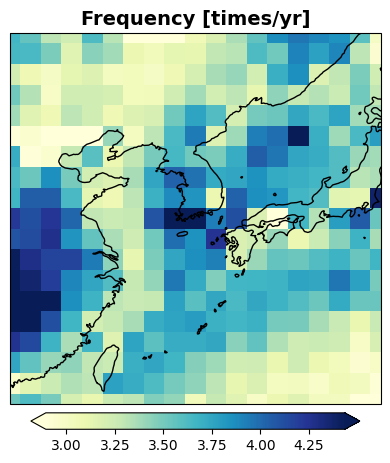

In [ ]:
# Individual plots
fig = plt.figure(figsize=(5,5))
ax  = plt.axes(projection=ccrs.PlateCarree())
im  = extreme_counts_avg.plot(ax=ax, transform=ccrs.PlateCarree(),
                cmap='YlGnBu',
                vmin=freq_vmin, vmax=freq_vmax,
                cbar_kwargs={"shrink":0.7, 'pad':0.02, 'location':'bottom'})
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.coastlines()
ax.set_title("Frequency [times/yr]", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

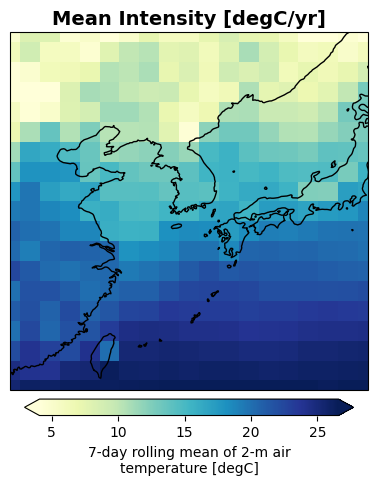

In [ ]:
fig = plt.figure(figsize=(5,5))
ax  = plt.axes(projection=ccrs.PlateCarree())
im  = extreme_avg_avg.plot(ax=ax, transform=ccrs.PlateCarree(),
                cmap='YlGnBu',
                vmin=intensity_vmin,
                vmax=intensity_vmax,
                cbar_kwargs={"shrink":0.7, 'pad':0.02, 'location':'bottom'})
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.coastlines()
ax.set_title(f"Mean Intensity [{unit}/yr]", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

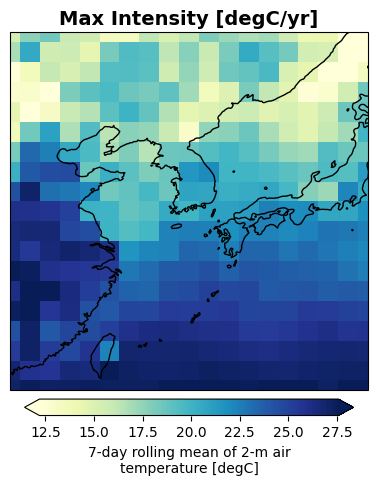

In [ ]:
fig = plt.figure(figsize=(5,5))
ax  = plt.axes(projection=ccrs.PlateCarree())
im  = extreme_max_avg.plot(ax=ax, transform=ccrs.PlateCarree(),
                cmap='YlGnBu',
                vmin=max_intensity_vmin,
                vmax=max_intensity_vmax,
                cbar_kwargs={"shrink":0.7, 'pad':0.02, 'location':'bottom'})
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.coastlines()
ax.set_title(f"Max Intensity [{unit}/yr]", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

## **Combined Visualization & Save Figure**

In [ ]:
# ====== Plot together
plot_info = [
    (extreme_counts_avg, "Frequency [times/yr]", freq_vmin, freq_vmax, "YlGnBu"),
    (extreme_avg_avg, f"Mean Intensity [{unit}/yr]", intensity_vmin, intensity_vmax, "YlGnBu"),
    (extreme_max_avg, f"Max Intensity [{unit}/yr]", max_intensity_vmin, max_intensity_vmax, "YlGnBu"),
]

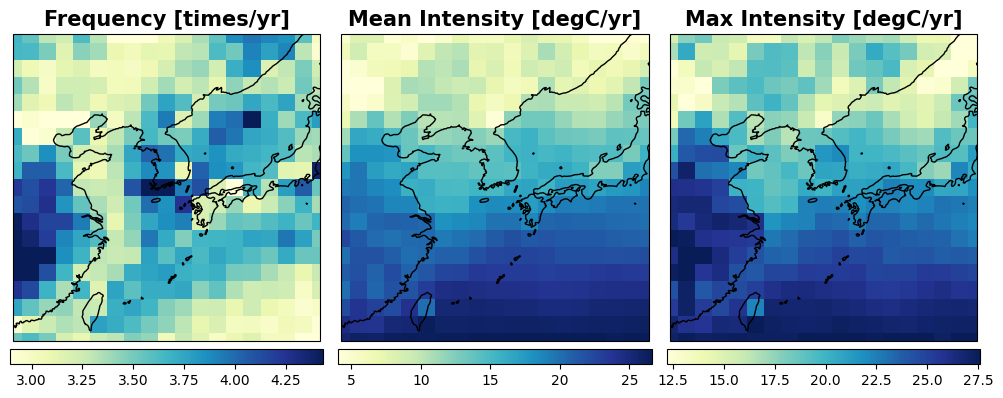

In [ ]:
fig, axes = plt.subplots(
    nrows=1, ncols=3,
    figsize=(10, 4),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

for ax, (data_plot, title, vmin, vmax, cmap) in zip(axes, plot_info):
    im = data_plot.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    ax.coastlines()
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.set_title(title, fontsize=15, fontweight="bold")
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="horizontal",
        pad=0.02,
    )

plt.tight_layout()
plt.savefig(os.path.join(PATH_save, f"{varname}_extreme_statistics_maps.png"),
            dpi=100, bbox_inches='tight')
plt.show()
plt.close()

## **Save statistics (NetCDF)**

Prepare dataset with frequency, mean intensity, and max intensity including metadata.


In [ ]:
# === Save statistics (NetCDF)
ds_extremes = xr.Dataset(
    {
        "frequency": extreme_counts_avg,
        "mean_intensity": extreme_avg_avg,
        "mean_max_intensity": extreme_max_avg,
    }
)
# Metadata
ds_extremes.frequency.attrs["units"] = "times/year"
ds_extremes.mean_intensity.attrs["units"] = f"{unit}/year"
ds_extremes.mean_max_intensity.attrs["units"] = f"{unit}/year"
ds_extremes.attrs["reference_period"] = f"{ref_syear}-{ref_eyear}"

In [ ]:
# Save as NetCDF
out_path = os.path.join(PATH_save,
                        f"{varname}_extreme_stats_{ref_syear}_{ref_eyear}_p{int(boundary*100)}.nc")
ds_extremes.to_netcdf(out_path)
print(f"Saved combined dataset to {out_path}")

Saved combined dataset to /content/drive/MyDrive/APCC/Results/AHT_extreme_stats_1991_2020_p90.nc
